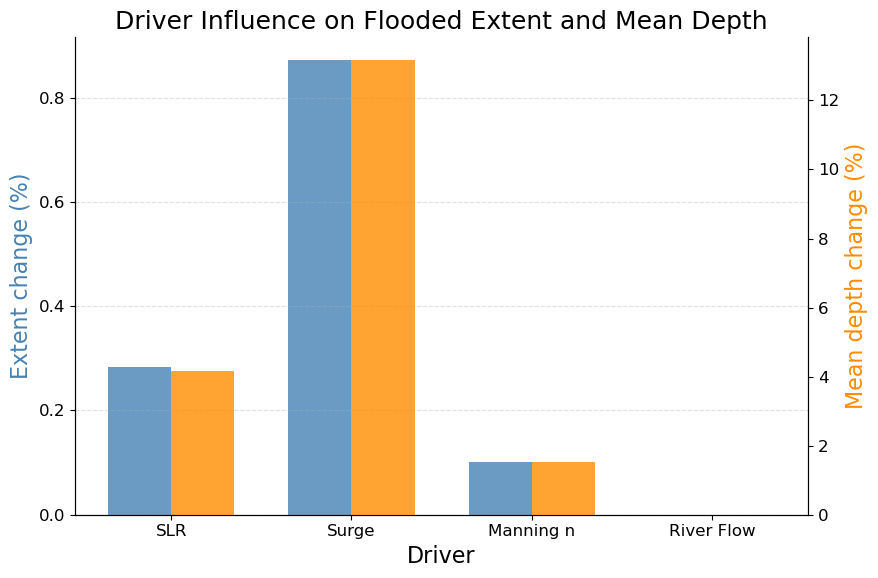

In [3]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd

# ---------- USER INPUTS ----------
THRESHOLD = 0.1  # meters
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

ref_file     = r"D:\Phd Research\sim_depth_100yr.tif"
slr_minus    = r"D:\Phd Research\sim_depth_100yr_0.8SLR.tif"
slr_plus     = r"D:\Phd Research\sim_depth_100yr_1.2SLR.tif"
surge_minus  = r"D:\Phd Research\sim_depth_100yr_surge_M10.tif"
surge_plus   = r"D:\Phd Research\sim_depth_100yr_surge_P10.tif"
manning_minus = r"D:\Phd Research\sim_depth_100yr_surge_M20_Mannings.tif"
manning_plus  = r"D:\Phd Research\sim_depth_100yr_surge_P20_Mannings.tif"
flow_minus   = r"D:\Phd Research\sim_depth_100yr_surge_Q_M20.tif"
flow_plus    = r"D:\Phd Research\sim_depth_100yr_surge_Q_P20.tif"

# ---------- FUNCTIONS ----------
def read_boundary(zip_path: str) -> gpd.GeoDataFrame:
    try:
        return gpd.read_file(f"zip://{zip_path}")
    except Exception:
        return gpd.read_file(zip_path)

def compute_extent_and_mean_depth(raster_path, boundary_gdf, threshold):
    with rasterio.open(raster_path) as src:
        bnd_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, bnd_proj.geometry, crop=True)
        data = out_img[0].astype("float64")
        nodata = src.nodata

    m = np.zeros(data.shape, dtype=bool)
    if nodata is not None:
        m |= (data == nodata)
    m |= (~np.isfinite(data)) | (data < 0) | (data <= threshold)

    flooded = ma.array(data, mask=m)
    px_w, px_h = abs(out_transform.a), abs(out_transform.e)
    cell_area_m2 = px_w * px_h

    flooded_cells = flooded.count()
    extent_km2 = flooded_cells * cell_area_m2 / 1e6
    mean_depth = float(flooded.mean()) if flooded_cells > 0 else 0.0
    return extent_km2, mean_depth

def central_diff_percent(E0, E_minus, E_plus):
    if E0 == 0:
        return 0.0
    dE = (E_plus - E_minus) / 2.0
    return (dE / E0) * 100.0

# ---------- MAIN ----------
boundary = read_boundary(boundary_zip)
E0_extent, E0_depth = compute_extent_and_mean_depth(ref_file, boundary, THRESHOLD)

drivers = {
    "SLR":        (slr_minus,    slr_plus),
    "Surge":      (surge_minus,  surge_plus),
    "Manning n":  (manning_minus, manning_plus),
    "River Flow": (flow_minus,   flow_plus),
}

rows = []
for drv, (f_minus, f_plus) in drivers.items():
    Em_ext, Em_dep = compute_extent_and_mean_depth(f_minus, boundary, THRESHOLD)
    Ep_ext, Ep_dep = compute_extent_and_mean_depth(f_plus, boundary, THRESHOLD)

    extent_pct = central_diff_percent(E0_extent, Em_ext, Ep_ext)
    depth_pct  = central_diff_percent(E0_depth,  Em_dep, Ep_dep)
    rows.append((drv, extent_pct, depth_pct))

df = pd.DataFrame(rows, columns=["Driver", "Extent_change_%", "MeanDepth_change_%"])

# ---------- PLOT ----------
x = np.arange(len(df))
width = 0.35

fig, ax1 = plt.subplots(figsize=(9, 6))
ax2 = ax1.twinx()

bars1 = ax1.bar(x - width/2, df["Extent_change_%"], width, color="steelblue", alpha=0.8)
bars2 = ax2.bar(x + width/2, df["MeanDepth_change_%"], width, color="darkorange", alpha=0.8)

ax1.set_xlabel("Driver")
ax1.set_ylabel("Extent change (%)", color="steelblue")
ax2.set_ylabel("Mean depth change (%)", color="darkorange")

ax1.set_xticks(x)
ax1.set_xticklabels(df["Driver"])

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Annotate values
for bar in bars1:
    y = bar.get_height()
    #ax1.text(bar.get_x() + bar.get_width()/2, y + np.sign(y)*0.5,
             #f"{y:.1f}", ha="center", va="bottom", color="steelblue")
for bar in bars2:
    y = bar.get_height()
    #ax2.text(bar.get_x() + bar.get_width()/2, y + np.sign(y)*0.5,
             #f"{y:.1f}", ha="center", va="bottom", color="darkorange")

ax1.set_title("Driver Influence on Flooded Extent and Mean Depth")

plt.tight_layout()
plt.show()
